In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'/Users/lbrice1/repos/ai_cheme_examples'

# Import packages

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from matplotlib import ticker


# Load data

In [ ]:
data_tep = pd.read_excel('data/TEP_selected_faults_0_1_4.xlsx', index_col=0).dropna()
X = data_tep.iloc[:, :-1]
y = data_tep.iloc[:, -1]

In [4]:
data_tep

,VA1,VA2,VA3,VA4,VA5,VA6,VA7,VA8,VA9,VA10,...,VA42,VA43,VA44,VA45,VA46,VA47,VA48,VA49,VA50,label
0,0.271033,3649.739415,4451.320791,9.223142,32.392900,47.559754,2798.975799,64.995825,122.898796,0.197826,...,62.806984,53.286709,26.662173,60.482854,24.229301,37.208198,46.430526,35.865322,12.930642,0
1,0.270831,3653.404787,4488.749834,9.212395,32.503406,47.388454,2799.619582,65.097593,122.883494,0.195043,...,62.820435,53.221669,26.690047,60.527401,24.035209,37.229301,46.431703,35.795922,11.717274,0
2,0.270483,3688.231984,4433.015687,9.236162,32.408470,47.836241,2800.848255,64.827252,122.920804,0.197604,...,62.838892,53.213996,26.706422,60.549280,24.372544,37.247810,46.452444,35.840589,10.745374,0
3,0.272138,3651.819407,4459.462199,9.192421,31.889586,47.893882,2800.819372,64.228681,122.896413,0.204403,...,62.850592,53.189197,26.769706,60.571278,24.911243,37.218895,46.421244,35.857312,10.331119,0
4,0.271177,3636.475344,4460.599294,9.275409,32.448601,47.540016,2800.969862,64.631039,122.894050,0.206725,...,62.850856,53.194539,26.420462,60.620575,25.392361,37.211732,46.440902,36.032292,11.210209,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1438,0.256935,3665.606688,4429.936562,9.177824,32.473144,47.638889,2799.606319,65.582458,122.891466,0.215606,...,63.001805,53.111387,25.315705,60.625604,26.260995,37.222226,46.436839,38.793495,11.904130,4
1439,0.256929,3682.279336,4424.564085,9.330472,32.312200,47.508742,2800.327610,65.674974,122.906402,0.213710,...,62.985427,53.155842,25.268210,60.530780,26.057862,37.233711,46.422676,38.933609,14.017483,4
1440,0.257741,3664.414361,4475.080788,9.277825,32.514460,47.569502,2800.505917,64.857079,122.907260,0.210212,...,62.998061,53.140325,25.487988,60.681045,25.759593,37.234999,46.452411,38.893797,9.701678,4
1441,0.258748,3671.352871,4435.231722,9.186020,32.271586,47.034317,2800.193177,64.807688,122.902361,0.210280,...,63.013690,53.118548,25.236415,60.818655,25.888843,37.193641,46.413963,38.944847,11.104700,4


# Data processing

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    shuffle=True,
                                                    random_state=0)

trainset = np.column_stack((X_train, y_train))
testset = np.column_stack((X_test, y_test))

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train = scaler.transform(X_train)

# Do dimensionality reduction

In [6]:
# use pacmap to reduce the dimension of the data
from pacmap import pacmap

def pacmap_reduce(X, n_components=2):
    """
    Reduce the dimensionality of the data using pacmap.
    :param X: The data to be reduced.
    :param n_components: The number of components to reduce to.
    :return: The reduced data.
    """
    pacmap_model = pacmap.PaCMAP(n_components=n_components, n_neighbors=100, FP_ratio=10, save_tree=True)
    X_reduced = pacmap_model.fit_transform(X)

    return pacmap_model, X_reduced

pacmap_model, X_train_reduced = pacmap_reduce(X_train, n_components=2)
X_test = scaler.transform(X_test)
X_test_reduced = pacmap_model.transform(X_test)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


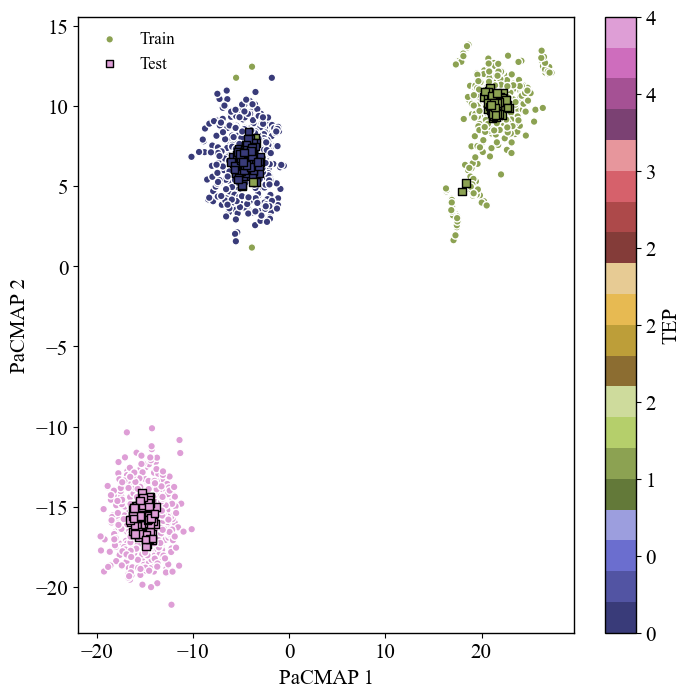

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(X_train_reduced[:, 0], X_train_reduced[:, 1], c=y_train, edgecolors='w', cmap='tab20b', s=30)
ax.scatter(X_test_reduced[:, 0], X_test_reduced[:, 1], marker='s', c=y_test, edgecolors='k', cmap='tab20b', s=30, alpha=1)
cbar = plt.colorbar(sc, label='TEP')
cbar.formatter = ticker.FormatStrFormatter('%.0f')
ax.set_xlabel('PaCMAP 1')
ax.set_ylabel('PaCMAP 2')

plt.legend(['Train', 'Test'], loc='best', fontsize=12, frameon=False)

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"
                                ] + plt.rcParams["font.serif"]
plt.rcParams['font.size']=15
plt.rcParams['axes.linewidth'] = 1 

plt.savefig('figures/example-3-1.png', dpi=300, bbox_inches='tight')
plt.show()